## Chapter 3 — Statistical Experiments and Significance Testing

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)   

### Tujuan
Chapter ini membahas bagaimana merancang eksperimen, membandingkan kelompok, melakukan hypothesis testing, menggunakan permutation test, memahami p-value dan error statistik, serta menggunakan t-test, ANOVA, chi-square test, multi-arm bandit, dan power/sample size.


## 1. Gambaran Umum Chapter

Dalam eksperimen statistik, tujuan utamanya adalah memperoleh bukti dari data untuk mengevaluasi sebuah hipotesis. Alur umumnya dapat diringkas menjadi:

**Formulate hypothesis → Design experiment → Collect data → Inference / conclusion**

Dalam data science, contoh yang umum adalah **A/B testing**, yaitu membandingkan dua perlakuan, misalnya dua desain halaman web, dua harga, atau dua versi fitur.

Konsep penting pada chapter ini:
1. A/B Testing
2. Hypothesis Tests
3. Resampling dan Permutation Test
4. Statistical Significance dan p-value
5. t-Tests
6. Multiple Testing
7. Degrees of Freedom
8. ANOVA dan F-statistic
9. Chi-Square Test
10. Multi-Arm Bandit Algorithm
11. Power dan Sample Size


## 2. Import Library dan Sumber Data

Dataset berikut mengikuti data yang digunakan pada ekosistem kode buku:
- `web_page_data.csv` — waktu sesi pada Page A dan Page B
- `four_sessions.csv` — waktu sesi pada empat halaman
- `click_rates.csv` — data klik beberapa headline
- `imanishi_data.csv` — data untuk contoh tambahan

Data diambil dari repository pendamping buku. Jika URL berubah, dataset dapat diunduh dari folder `data` pada repository resmi buku.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import fisher_exact
from statsmodels.stats.power import TTestIndPower

sns.set_theme(style="whitegrid")
np.random.seed(42)

BASE_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

session_times = pd.read_csv(BASE_URL + "web_page_data.csv")
four_sessions = pd.read_csv(BASE_URL + "four_sessions.csv")
click_rate = pd.read_csv(BASE_URL + "click_rates.csv")

# Pada dataset buku, waktu ditampilkan sebagai proporsi sehingga dikalikan 100
if "Time" in session_times.columns:
    session_times["Time"] = session_times["Time"] * 100

print("web_page_data:")
display(session_times.head())
print("\nfour_sessions:")
display(four_sessions.head())
print("\nclick_rates:")
display(click_rate.head())


web_page_data:


,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0



four_sessions:


,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172



click_rates:


,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12


## 3. A/B Testing

**A/B test** adalah eksperimen yang membandingkan dua perlakuan.

Contoh:
- A = halaman web lama
- B = halaman web baru

Satu **test statistic** perlu ditetapkan untuk mengukur efek perlakuan. Pada contoh ini digunakan **rata-rata waktu sesi**.

### Mengapa control group diperlukan?
Control group menyediakan baseline pembanding. Tanpa pembanding yang sesuai, perubahan yang diamati dapat berasal dari faktor lain atau variasi acak, bukan semata-mata dari treatment.

### Mengapa randomization penting?
Random assignment membantu membuat karakteristik subjek pada kelompok lebih sebanding sehingga pengaruh treatment dapat dievaluasi dengan lebih baik.


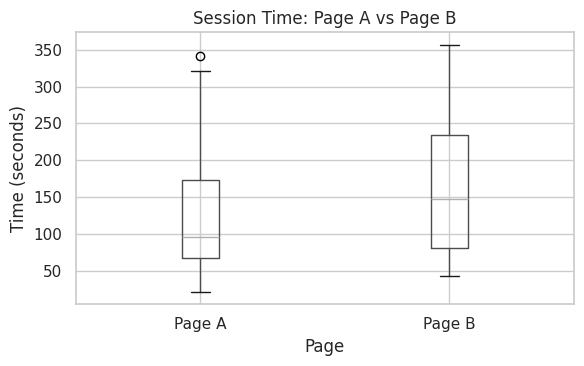

Mean Page A : 126.33 seconds
Mean Page B : 162.00 seconds
Observed difference (B - A): 35.67 seconds


In [3]:
# Visualisasi waktu sesi untuk Page A dan Page B
fig, ax = plt.subplots(figsize=(6, 4))
session_times.boxplot(column="Time", by="Page", ax=ax)
ax.set_title("Session Time: Page A vs Page B")
ax.set_xlabel("Page")
ax.set_ylabel("Time (seconds)")
plt.suptitle("")
plt.tight_layout()
plt.show()

mean_a = session_times.loc[session_times["Page"] == "Page A", "Time"].mean()
mean_b = session_times.loc[session_times["Page"] == "Page B", "Time"].mean()
observed_diff = mean_b - mean_a

print(f"Mean Page A : {mean_a:.2f} seconds")
print(f"Mean Page B : {mean_b:.2f} seconds")
print(f"Observed difference (B - A): {observed_diff:.2f} seconds")


### Interpretasi

Perbedaan rata-rata di atas adalah **efek yang diamati (observed effect)**. Namun, perbedaan tersebut belum otomatis berarti bahwa Page B benar-benar menghasilkan perubahan.

Pertanyaan statistik berikutnya adalah:

> Jika Page A dan Page B sebenarnya tidak memiliki perbedaan, seberapa sering perbedaan sebesar ini dapat muncul hanya karena random chance?

Pertanyaan tersebut menjadi dasar **null hypothesis** dan **permutation test**.


## 4. Hypothesis Tests

Hypothesis testing menggunakan dua hipotesis:

- **Null hypothesis (H₀):** tidak ada efek/perbedaan yang relevan; perbedaan yang terlihat dapat dijelaskan oleh chance.
- **Alternative hypothesis (H₁):** terdapat efek/perbedaan.

Untuk A/B test:
- H₀: distribusi hasil Page A dan Page B dapat diperlakukan sebagai berasal dari proses yang sama.
- H₁: terdapat perbedaan antara Page A dan Page B.

### One-way vs two-way
- **One-way (one-sided):** hanya mempertimbangkan penyimpangan ke satu arah.
- **Two-way (two-sided):** mempertimbangkan penyimpangan ke dua arah.

Pilihan hipotesis harus ditentukan berdasarkan pertanyaan eksperimen, bukan setelah melihat hasil.


## 5. Resampling — Permutation Test

Permutation test membangun **null distribution** dengan menggabungkan data kelompok, mengacak label kelompok, lalu menghitung kembali test statistic berkali-kali.

Langkah:
1. Gabungkan hasil A dan B.
2. Acak/permute label kelompok.
3. Bagi kembali menjadi ukuran kelompok semula.
4. Hitung perbedaan rata-rata.
5. Ulangi banyak kali.
6. Bandingkan hasil permutation dengan observed difference.

Jika proporsi hasil permutation yang sama atau lebih ekstrem cukup besar, observed difference masih konsisten dengan null model.


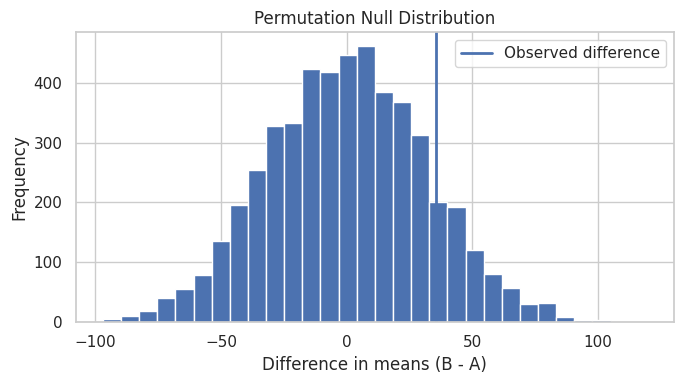

Observed difference: 35.67
Permutation p-value (one-sided): 0.1298


In [4]:
def permutation_difference(values, n_a, n_b, rng):
    idx = rng.permutation(len(values))
    a = values[idx[:n_a]]
    b = values[idx[n_a:n_a+n_b]]
    return b.mean() - a.mean()

values = session_times["Time"].to_numpy()
n_a = (session_times["Page"] == "Page A").sum()
n_b = (session_times["Page"] == "Page B").sum()

rng = np.random.default_rng(42)
perm_diffs = np.array([
    permutation_difference(values, n_a, n_b, rng)
    for _ in range(5000)
])

p_value_perm = np.mean(perm_diffs >= observed_diff)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_diffs, bins=30)
ax.axvline(observed_diff, linewidth=2, label="Observed difference")
ax.set_xlabel("Difference in means (B - A)")
ax.set_ylabel("Frequency")
ax.set_title("Permutation Null Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed difference: {observed_diff:.2f}")
print(f"Permutation p-value (one-sided): {p_value_perm:.4f}")


### Interpretasi permutation test

Permutation test memberikan distribusi pembanding yang dibangun dari data dengan asumsi null hypothesis.

**Catatan:** p-value bukan probabilitas bahwa H₀ benar. Secara konseptual, p-value mengukur seberapa sering hasil yang sama ekstrem atau lebih ekstrem dapat muncul menurut chance model/null model.


## 6. Statistical Significance, p-Value, dan Alpha

**p-value** adalah ukuran seberapa ekstrem hasil yang diamati dibandingkan dengan hasil yang diharapkan dari null model.

**Alpha (α)** adalah threshold yang ditetapkan sebelum pengujian, misalnya 0,05.

Aturan keputusan yang umum:
- p-value < α → hasil disebut statistically significant terhadap threshold tersebut.
- p-value ≥ α → belum ada bukti yang cukup untuk menolak H₀ pada threshold tersebut.

Statistical significance tidak sama dengan practical significance. Efek yang sangat kecil dapat menjadi signifikan pada sampel besar, sementara efek yang cukup besar dapat sulit dideteksi pada sampel kecil.


## 7. Type I dan Type II Error

Dua jenis kesalahan utama:

- **Type I error:** menolak H₀ padahal H₀ benar — false positive.
- **Type II error:** gagal menolak H₀ padahal H₁ benar — false negative.

Hubungan sederhana:
- α berkaitan dengan pengendalian risiko Type I error.
- Power berkaitan dengan kemampuan mendeteksi efek ketika efek tersebut memang ada.

Tidak menolak H₀ **bukan berarti membuktikan H₀ benar**.


## 8. t-Tests

t-test digunakan untuk menguji perbedaan mean ketika test statistic dibandingkan dengan t-distribution.

Pada A/B test dengan data numerik, salah satu pendekatan adalah **independent two-sample t-test**.

Di Python, `scipy.stats.ttest_ind` dapat digunakan. Parameter `equal_var=False` menggunakan Welch's t-test, yang tidak mengharuskan varians kedua kelompok sama.


In [5]:
group_a = session_times.loc[session_times["Page"] == "Page A", "Time"]
group_b = session_times.loc[session_times["Page"] == "Page B", "Time"]

t_result = stats.ttest_ind(group_b, group_a, equal_var=False)

print(f"t-statistic: {t_result.statistic:.4f}")
print(f"p-value    : {t_result.pvalue:.4f}")


t-statistic: 1.0983
p-value    : 0.2815


### Interpretasi t-test

t-statistic menstandarkan perbedaan mean terhadap variasi data. p-value kemudian digunakan untuk membandingkan hasil tersebut dengan null model berdasarkan t-distribution.

Permutation test dan t-test menjawab pertanyaan inferensial yang berkaitan, tetapi pendekatannya berbeda:
- permutation test membangun null distribution melalui resampling,
- t-test menggunakan distribusi teoritis sebagai pendekatan.


## 9. Multiple Testing

Ketika banyak hipotesis diuji, peluang memperoleh setidaknya satu hasil false positive meningkat.

Misalnya ada banyak variasi halaman atau banyak metrik yang diuji. Jika masing-masing pengujian menggunakan α = 0,05, maka secara keseluruhan risiko mendapatkan hasil signifikan secara kebetulan dapat menjadi lebih besar.

Salah satu pendekatan sederhana adalah **Bonferroni correction**:

α_adjusted = α / m

dengan `m` = jumlah pengujian.


In [6]:
alpha = 0.05
m = 10
bonferroni_alpha = alpha / m

print(f"Original alpha   : {alpha}")
print(f"Number of tests  : {m}")
print(f"Bonferroni alpha : {bonferroni_alpha}")


Original alpha   : 0.05
Number of tests  : 10
Bonferroni alpha : 0.005


## 10. Degrees of Freedom

**Degrees of freedom (df)** menggambarkan jumlah informasi independen yang tersedia untuk mengestimasi parameter setelah mempertimbangkan constraint tertentu.

Contoh:
- variance sampel biasanya menggunakan `n - 1` degrees of freedom.
- pada two-sample t-test, degrees of freedom bergantung pada ukuran sampel dan asumsi varians.
- distribusi t berubah bentuk sesuai df; semakin besar df, bentuknya semakin mendekati normal.



In [7]:
# Welch's t-test dan degrees of freedom
welch = stats.ttest_ind(group_b, group_a, equal_var=False)

n1, n2 = len(group_b), len(group_a)
s1, s2 = group_b.var(ddof=1), group_a.var(ddof=1)

df_welch = (s1/n1 + s2/n2)**2 / (
    (s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1)
)

print(f"Welch t-statistic : {welch.statistic:.4f}")
print(f"Welch df          : {df_welch:.2f}")


Welch t-statistic : 1.0983
Welch df          : 27.69


## 11. ANOVA dan F-Statistic

Jika hanya ada dua kelompok, t-test sering digunakan. Jika terdapat beberapa kelompok, **ANOVA (Analysis of Variance)** dapat digunakan untuk menguji apakah terdapat perbedaan mean antar kelompok.

Contoh pada buku menggunakan empat halaman web.

Hipotesis:
- H₀: semua group mean sama.
- H₁: setidaknya ada satu group mean yang berbeda.

ANOVA menggunakan **F-statistic**, yaitu perbandingan variasi antar-group terhadap variasi di dalam group.


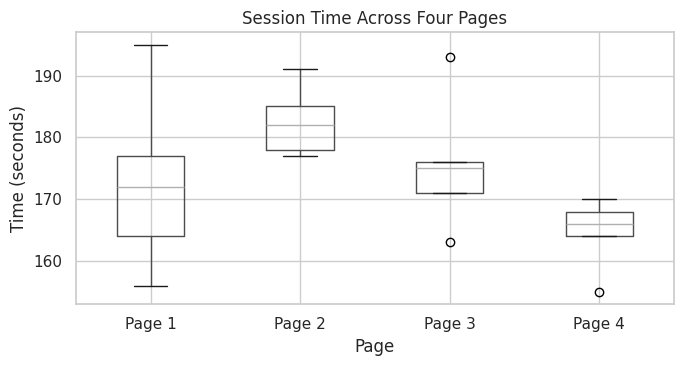

Group means:
Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64
Variance of group means: 55.4267


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
four_sessions.boxplot(column="Time", by="Page", ax=ax)
ax.set_title("Session Time Across Four Pages")
ax.set_xlabel("Page")
ax.set_ylabel("Time (seconds)")
plt.suptitle("")
plt.tight_layout()
plt.show()

grouped_means = four_sessions.groupby("Page")["Time"].mean()
observed_variance = grouped_means.var()

print("Group means:")
print(grouped_means)
print(f"Variance of group means: {observed_variance:.4f}")


In [9]:
# One-way ANOVA menggunakan scipy
groups = [
    group["Time"].to_numpy()
    for _, group in four_sessions.groupby("Page")
]

anova_result = stats.f_oneway(*groups)

print(f"F-statistic: {anova_result.statistic:.4f}")
print(f"p-value    : {anova_result.pvalue:.4f}")


F-statistic: 2.7398
p-value    : 0.0776


### Permutation ANOVA

ANOVA juga dapat dijelaskan dengan pendekatan resampling: jika H₀ benar, label halaman dapat diacak sementara nilai waktu tetap sama. Kemudian dihitung kembali variasi antar-mean.



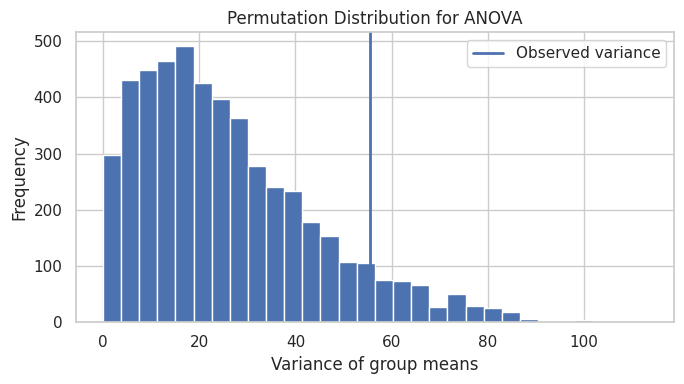

Permutation ANOVA p-value: 0.0812


In [10]:
def permutation_anova_stat(df, rng):
    shuffled = df.copy()
    shuffled["Time"] = rng.permutation(shuffled["Time"].to_numpy())
    return shuffled.groupby("Page")["Time"].mean().var()

rng = np.random.default_rng(42)
perm_variances = np.array([
    permutation_anova_stat(four_sessions, rng)
    for _ in range(5000)
])

p_value_anova_perm = np.mean(perm_variances >= observed_variance)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_variances, bins=30)
ax.axvline(observed_variance, linewidth=2, label="Observed variance")
ax.set_xlabel("Variance of group means")
ax.set_ylabel("Frequency")
ax.set_title("Permutation Distribution for ANOVA")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Permutation ANOVA p-value: {p_value_anova_perm:.4f}")


## 12. Chi-Square Test

Chi-square test digunakan untuk data berbentuk **count/frequency** dan sering digunakan untuk menguji hubungan antara dua variabel kategorikal.

Contoh pada chapter adalah perbandingan click rate untuk beberapa headline.

Hipotesis:
- H₀: headline dan status click independen.
- H₁: terdapat hubungan antara headline dan status click.



In [11]:
# Membentuk contingency table dari data click rate
click_table = click_rate.pivot(
    index="Headline",
    columns="Click",
    values="Rate"
)

print(click_table)

chi2_result = stats.chi2_contingency(click_table)

chi2_stat, chi2_p, chi2_dof, expected = chi2_result

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom : {chi2_dof}")
print(f"p-value             : {chi2_p:.4f}")

expected_df = pd.DataFrame(
    expected,
    index=click_table.index,
    columns=click_table.columns
)

print("\nExpected counts:")
display(expected_df)


Click       Click  No-click
Headline                   
Headline A     14       986
Headline B      8       992
Headline C     12       988
Chi-square statistic: 1.6659
Degrees of freedom : 2
p-value             : 0.4348

Expected counts:


Click,Click,No-click
Headline,,
Headline A,11.333333,988.666667
Headline B,11.333333,988.666667
Headline C,11.333333,988.666667


### Chi-square: resampling approach

Selain pendekatan teoritis, chi-square dapat dikombinasikan dengan resampling. Pendekatan ini berguna sebagai cara membangun null distribution secara empiris.

Untuk tabel dengan jumlah observasi kecil, **Fisher's Exact Test** juga dapat dipertimbangkan untuk tabel 2×2.


In [12]:
# Contoh Fisher's Exact Test pada tabel 2x2.
# Jika dataset click_rate memiliki lebih dari 2 headline,
# kita ambil dua headline pertama sebagai demonstrasi metode.
if click_table.shape == (2, 2):
    odds_ratio, fisher_p = fisher_exact(click_table.to_numpy())
    print(f"Odds ratio: {odds_ratio:.4f}")
    print(f"Fisher exact p-value: {fisher_p:.4f}")
else:
    print("Fisher's Exact Test membutuhkan tabel 2x2; dataset ini memiliki bentuk:",
          click_table.shape)


Fisher's Exact Test membutuhkan tabel 2x2; dataset ini memiliki bentuk: (3, 2)


## 13. Multi-Arm Bandit Algorithm

A/B testing biasanya melakukan random assignment antara dua pilihan. Jika pilihan lebih dari dua, masalah dapat berkembang menjadi **multi-arm bandit**.

Tujuannya adalah menyeimbangkan:
- **exploration** — mencoba pilihan untuk mendapatkan informasi,
- **exploitation** — lebih sering memilih pilihan yang sementara terlihat memberikan hasil terbaik.

Salah satu strategi sederhana adalah **epsilon-greedy**:
- dengan probabilitas ε, lakukan exploration;
- dengan probabilitas `1 - ε`, pilih arm dengan estimasi reward tertinggi.

Contoh berikut adalah simulasi pembelajaran, bukan data eksperimen buku.


In [13]:
# Simulasi epsilon-greedy untuk 3 arm
true_rates = np.array([0.08, 0.10, 0.07])
n_rounds = 1000
epsilon = 0.10

rng = np.random.default_rng(42)
counts = np.zeros(3, dtype=int)
rewards = np.zeros(3, dtype=int)

for _ in range(n_rounds):
    if rng.random() < epsilon:
        arm = rng.integers(0, 3)  # exploration
    else:
        estimated_rates = np.divide(
            rewards, counts,
            out=np.zeros(3, dtype=float),
            where=counts > 0
        )
        # Pastikan setiap arm pernah dicoba
        if np.any(counts == 0):
            arm = np.where(counts == 0)[0][0]
        else:
            arm = int(np.argmax(estimated_rates))

    reward = rng.random() < true_rates[arm]
    counts[arm] += 1
    rewards[arm] += int(reward)

estimated_rates = rewards / counts

result_bandit = pd.DataFrame({
    "Arm": ["A", "B", "C"],
    "True rate": true_rates,
    "Selections": counts,
    "Rewards": rewards,
    "Estimated rate": estimated_rates
})

display(result_bandit)


,Arm,True rate,Selections,Rewards,Estimated rate
0,A,0.08,73,3,0.041096
1,B,0.10,418,41,0.098086
2,C,0.07,509,37,0.072692


## 14. Power dan Sample Size

**Statistical power** adalah probabilitas untuk mendeteksi efek ketika efek tersebut memang ada, dengan asumsi model dan parameter yang digunakan benar.

Power dipengaruhi oleh:
- effect size,
- sample size,
- significance level α,
- variability.

Secara umum, semakin besar sample size, semakin besar kemampuan mendeteksi efek yang sama.


In [14]:
analysis = TTestIndPower()

effect_size = 0.5
alpha = 0.05
power_target = 0.80

required_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power_target,
    ratio=1.0,
    alternative="two-sided"
)

print(f"Effect size : {effect_size}")
print(f"Alpha       : {alpha}")
print(f"Target power: {power_target}")
print(f"Required sample size per group (approx.): {np.ceil(required_n):.0f}")


Effect size : 0.5
Alpha       : 0.05
Target power: 0.8
Required sample size per group (approx.): 64


## 16. Analisis dan Kesimpulan

### Analisis
Chapter 3 menunjukkan bahwa perbedaan yang terlihat pada data eksperimen belum cukup untuk menyatakan adanya efek. Perlu ada **test statistic** dan **null model** yang sesuai untuk menilai apakah perbedaan tersebut masih masuk akal jika hanya disebabkan oleh random chance.

Permutation test memberikan cara yang intuitif untuk membangun null distribution dari data. t-test dan ANOVA menyediakan pendekatan berbasis distribusi teoritis, sedangkan chi-square digunakan untuk data kategorikal/count.

Ketika banyak pengujian dilakukan, risiko Type I error perlu diperhatikan. Selain itu, desain eksperimen dan sample size berpengaruh terhadap kemampuan mendeteksi efek.

### Kesimpulan
Hal terpenting dari chapter ini adalah bahwa **statistical significance merupakan bagian dari proses inferensi, bukan satu-satunya ukuran kebermaknaan suatu hasil**. Dalam data science, eksperimen sebaiknya dirancang dengan hipotesis, control/comparison yang jelas, metrik yang ditentukan sebelumnya, metode pengujian yang sesuai, serta pertimbangan power dan sample size.
